# Chapter 13: Advanced Series and DataFrame Methods

**Companion notebook** for *Beginner's Guide to Pandas* by Ravi Shankar

Run each cell in order. Exercises are at the end.

In [1]:
import pandas as pd
import numpy as np

# Advanced Series and DataFrame Methods

Pandas offers many advanced methods to streamline data analysis, transformation, and optimization. This guide explains *when* and *why* to use each method with practical examples.

---

## Series Methods

### `interpolate()`: Fill Missing Values Using Mathematical Estimation

**What it does:** Estimates missing values based on surrounding data points using mathematical methods, rather than simply copying values forward or backward.

**When to use:**
- Time-series data with small gaps (stock prices, temperature readings)
- When you need realistic estimates rather than repeated values
- When data has a clear trend

**Common interpolation methods:**

In [ ]:
import pandas as pd
import numpy as np

# Create a Series with missing values
s = pd.Series([1.0, np.nan, np.nan, 4.0, 5.0, np.nan, 7.0])
print("Original Series:")
print(s)
print("\n" + "="*50 + "\n")

# Method 1: Linear interpolation (default)
# Draws a straight line between known points
print("Linear interpolation (default):")
print(s.interpolate(method='linear'))
print("→ Fills gaps with evenly-spaced values between endpoints\n")

# Method 2: Forward fill
# Repeats the last known value
print("Forward fill:")
print(s.ffill())
print("→ Repeats previous value until a new value appears\n")

# Method 3: Polynomial interpolation
# Fits a curve through the data (more sophisticated)
print("Polynomial interpolation (order=2):")
print(s.interpolate(method='polynomial', order=2))
print("→ Fits a curved line for smoother transitions\n")

# Limit consecutive fills
print("Linear with limit=1 (fill max 1 consecutive NaN):")
print(s.interpolate(method='linear', limit=1))
print("→ Stops filling after 1 consecutive missing value")

**Output:**
```
Original Series:
0    1.0
1    NaN
2    NaN
3    4.0
4    5.0
5    NaN
6    7.0
dtype: float64

==================================================

Linear interpolation (default):
0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
6    7.0
dtype: float64
→ Fills gaps with evenly-spaced values between endpoints

Pad method (forward fill):
0    1.0
1    1.0
2    1.0
3    4.0
4    5.0
5    5.0
6    7.0
dtype: float64
→ Repeats previous value until a new value appears

Polynomial interpolation (order=2):
0    1.000000
1    1.666667
2    2.666667
3    4.000000
4    5.000000
5    6.000000
6    7.000000
dtype: float64
→ Fits a curved line for smoother transitions

Linear with limit=1 (fill max 1 consecutive NaN):
0    1.0
1    2.0
2    NaN
3    4.0
4    5.0
5    6.0
6    7.0
dtype: float64
→ Stops filling after 1 consecutive missing value
```

**Real-world example:**

In [3]:
import pandas as pd
import numpy as np

# Stock price with missing data
prices = pd.Series([100.0, np.nan, np.nan, 102.0, 103.0])
print("Stock prices (raw):", prices.tolist())
print("Interpolated:", prices.interpolate().tolist())

# Output: Stock prices (raw): [100.0, nan, nan, 102.0, 103.0]
#         Interpolated: [100.0, 100.67, 101.33, 102.0, 103.0]

Stock prices (raw): [100.0, nan, nan, 102.0, 103.0]
Interpolated: [100.0, 100.66666666666667, 101.33333333333333, 102.0, 103.0]


---

### `isin()`: Filter Data by Multiple Values

**What it does:** Checks if each value in a Series matches any value in a provided list, returning a boolean Series for filtering.

**When to use:**
- Filtering for multiple specific values (e.g., "show rows where status is 'active' OR 'pending'")
- Validating that values are in an allowed set
- More efficient and readable than multiple `==` comparisons

**Comparison: `isin()` vs. `==`**

In [4]:
import pandas as pd

# Sample data
df = pd.DataFrame({
    'product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Headphones'],
    'status': ['active', 'inactive', 'active', 'pending', 'active'],
    'price': [999, 25, 75, 299, 149]
})

print("Original DataFrame:")
print(df)
print("\n" + "="*50 + "\n")

# Using isin() - CLEANER for multiple values
print("Using isin() - Get active OR pending items:")
filtered = df[df['status'].isin(['active', 'pending'])]
print(filtered)
print("\n" + "="*50 + "\n")

# Using multiple == comparisons - MORE VERBOSE
print("Using == comparisons - Same result but messier:")
filtered_alt = df[(df['status'] == 'active') | (df['status'] == 'pending')]
print(filtered_alt)
print("\n" + "="*50 + "\n")

# Invert with ~ to get items NOT in the list
print("Using ~isin() - Get items that are NOT active or pending:")
print(df[~df['status'].isin(['active', 'pending'])])
print("\n" + "="*50 + "\n")

# Check if prices are in a specific set
print("Get products with price in [25, 75, 149]:")
print(df[df['price'].isin([25, 75, 149])])

Original DataFrame:
      product    status  price
0      Laptop    active    999
1       Mouse  inactive     25
2    Keyboard    active     75
3     Monitor   pending    299
4  Headphones    active    149


Using isin() - Get active OR pending items:
      product   status  price
0      Laptop   active    999
2    Keyboard   active     75
3     Monitor  pending    299
4  Headphones   active    149


Using == comparisons - Same result but messier:
      product   status  price
0      Laptop   active    999
2    Keyboard   active     75
3     Monitor  pending    299
4  Headphones   active    149


Using ~isin() - Get items that are NOT active or pending:
  product    status  price
1   Mouse  inactive     25


Get products with price in [25, 75, 149]:
      product    status  price
1       Mouse  inactive     25
2    Keyboard    active     75
4  Headphones    active    149


**Output:**
```
Original DataFrame:
      product    status  price
0      Laptop    active    999
1       Mouse  inactive     25
2    Keyboard    active     75
3     Monitor   pending    299
4  Headphones    active    149

==================================================

Using isin() - Get active OR pending items:
      product   status  price
0      Laptop   active    999
2    Keyboard   active     75
3     Monitor  pending    299
4  Headphones   active    149

==================================================

Using == comparisons - Same result but messier:
      product   status  price
0      Laptop   active    999
2    Keyboard   active     75
3     Monitor  pending    299
4  Headphones   active    149

==================================================

Using ~isin() - Get items that are NOT active or pending:
  product    status  price
1   Mouse  inactive     25

==================================================

Get products with price in [25, 75, 149]:
      product    status  price
1       Mouse  inactive     25
2    Keyboard    active     75
4  Headphones    active    149
```

---

### `notna()` and `notnull()`: Detect Non-Missing Values

**What it does:** Returns a boolean Series indicating which values are NOT missing (NaN/None).

**Note:** `notna()` and `notnull()` are aliases—they perform identically. Use `notna()` for clarity.

In [5]:
import pandas as pd
import numpy as np

s = pd.Series([1, np.nan, 3, None, 5, np.nan])
print("Original Series:")
print(s)
print("\n" + "="*50 + "\n")

# Detect non-missing values
print("Using notna():")
print(s.notna())
print("\n" + "="*50 + "\n")

# Filter to keep only non-missing values
print("Keep only non-missing values:")
print(s[s.notna()])
print("\n" + "="*50 + "\n")

# Count non-missing values
print(f"Count of non-missing values: {s.notna().sum()}")

Original Series:
0    1.0
1    NaN
2    3.0
3    NaN
4    5.0
5    NaN
dtype: float64


Using notna():
0     True
1    False
2     True
3    False
4     True
5    False
dtype: bool


Keep only non-missing values:
0    1.0
2    3.0
4    5.0
dtype: float64


Count of non-missing values: 3


**Output:**
```
Original Series:
0    1.0
1    NaN
2    3.0
3    NaN
4    5.0
5    NaN
dtype: float64

==================================================

Using notna():
0     True
1    False
2     True
3    False
4     True
5    False
dtype: bool

==================================================

Keep only non-missing values:
0    1.0
2    3.0
4    5.0
dtype: float64

==================================================

Count of non-missing values: 3
```

---

### `nsmallest()` and `nlargest()`: Get Top/Bottom N Values Efficiently

**What it does:** Returns the n smallest or largest values without sorting the entire Series. More efficient than sorting when you only need a few values.

**When to use:**
- Finding top 10 products by sales
- Identifying bottom 5 performers
- Large datasets (>100k rows) where you only need a subset

**Comparison: `nsmallest()` vs. `sort_values()`**

In [6]:
import pandas as pd
import numpy as np

# Create sample data
s = pd.Series([5, 2, 8, 1, 9, 3, 7, 4, 6])
print("Original Series:")
print(s)
print("\n" + "="*50 + "\n")

# Get 3 smallest values
print("Get 3 smallest values using nsmallest():")
print(s.nsmallest(3))
print("→ Returns values in sorted order\n")

# Get 3 largest values
print("Get 3 largest values using nlargest():")
print(s.nlargest(3))
print("→ Returns values in sorted order\n")

# Compare with sort_values() - sorts everything (less efficient)
print("Using sort_values() for comparison:")
print(s.sort_values().head(3))
print("→ Sorts entire Series (less efficient for large data)\n")

# With a DataFrame - get top performers
df = pd.DataFrame({
    'employee': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'sales': [5000, 8500, 3200, 9100, 6700]
})
print("Top 2 salespeople:")
print(df.nlargest(2, 'sales'))

Original Series:
0    5
1    2
2    8
3    1
4    9
5    3
6    7
7    4
8    6
dtype: int64


Get 3 smallest values using nsmallest():
3    1
1    2
5    3
dtype: int64
→ Returns values in sorted order

Get 3 largest values using nlargest():
4    9
2    8
6    7
dtype: int64
→ Returns values in sorted order

Using sort_values() for comparison:
3    1
1    2
5    3
dtype: int64
→ Sorts entire Series (less efficient for large data)

Top 2 salespeople:
  employee  sales
3    Diana   9100
1      Bob   8500


**Output:**
```
Original Series:
0    5
1    2
2    8
3    1
4    9
5    3
6    7
7    4
8    6
dtype: int64

==================================================

Get 3 smallest values using nsmallest():
3    1
1    2
5    3
dtype: int64
→ Returns values in sorted order

Get 3 largest values using nlargest():
4    9
2    8
6    7
dtype: int64
→ Returns values in sorted order

Using sort_values() for comparison:
3    1
1    2
5    3
dtype: int64
→ Sorts entire Series (less efficient for large data)

Top 2 salespeople:
  employee  sales
3    Diana   9100
1      Bob   8500
```

---

## DataFrame Methods

### `eval()`: Evaluate Expressions Efficiently

**What it does:** Evaluates mathematical expressions as strings in a single operation, avoiding intermediate Series creation.

**When to use:**
- Large datasets (>100k rows) with multiple column operations
- Complex expressions with many operations
- When you want cleaner, more readable code

**Performance benefit:**

In [7]:
import pandas as pd
import numpy as np

# Create a large DataFrame
np.random.seed(42)
df = pd.DataFrame({
    'a': np.random.randn(100000),
    'b': np.random.randn(100000),
    'c': np.random.randn(100000)
})

print("DataFrame shape:", df.shape)
print("\n" + "="*50 + "\n")

# Method 1: Traditional approach (creates intermediate Series)
result1 = df['a'] + df['b'] * df['c']
print("Traditional approach:")
print(result1.head())
print("\n" + "="*50 + "\n")

# Method 2: Using eval() (single operation)
result2 = df.eval('a + b * c')
print("Using eval():")
print(result2.head())
print("\n" + "="*50 + "\n")

# Both produce the same result
print("Results are equal:", result1.equals(result2))

DataFrame shape: (100000, 3)


Traditional approach:
0    2.106339
1   -0.029397
2   -0.117376
3    2.382928
4   -0.121969
dtype: float64


Using eval():
0    2.106339
1   -0.029397
2   -0.117376
3    2.382928
4   -0.121969
dtype: float64


Results are equal: True


**Practical examples:**

In [8]:
import pandas as pd

# Sales data
df = pd.DataFrame({
    'quantity': [10, 20, 15, 30],
    'unit_price': [100, 50, 75, 200],
    'tax_rate': [0.1, 0.1, 0.15, 0.1]
})

print("Original DataFrame:")
print(df)
print("\n" + "="*50 + "\n")

# Calculate total with tax using eval()
df['total'] = df.eval('quantity * unit_price * (1 + tax_rate)')
print("After adding total column with eval():")
print(df)

Original DataFrame:
   quantity  unit_price  tax_rate
0        10         100      0.10
1        20          50      0.10
2        15          75      0.15
3        30         200      0.10


After adding total column with eval():
   quantity  unit_price  tax_rate    total
0        10         100      0.10  1100.00
1        20          50      0.10  1100.00
2        15          75      0.15  1293.75
3        30         200      0.10  6600.00


---

### `ewm()`: Exponentially Weighted Moving Average

**What it does:** Calculates weighted averages where recent values have more influence than older values. Ideal for smoothing trends in time-series data.

**When to use:**
- Stock price trends (recent prices matter more)
- Smoothing noisy data
- Financial indicators
- Any time-series where recent data is more relevant

**Understanding the `span` parameter:**
- `span=2`: Recent values have much more weight (responsive)
- `span=10`: More balanced weighting across recent history
- Larger span = smoother curve (lags behind changes)

In [9]:
import pandas as pd
import numpy as np

# Sample time-series data (e.g., daily stock prices)
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=20)
prices = pd.Series(
    [100 + np.random.randn() * 2 for _ in range(20)],
    index=dates
)

print("Original prices (first 10):")
print(prices.head(10))
print("\n" + "="*50 + "\n")

# Calculate exponentially weighted mean with different spans
ewm_span2 = prices.ewm(span=2).mean()
ewm_span5 = prices.ewm(span=5).mean()
ewm_span10 = prices.ewm(span=10).mean()

print("Exponentially Weighted Means (first 10):")
comparison = pd.DataFrame({
    'original': prices,
    'ewm_span=2': ewm_span2,
    'ewm_span=5': ewm_span5,
    'ewm_span=10': ewm_span10
})
print(comparison.head(10))
print("\n" + "="*50 + "\n")

print("Notice how:")
print("- span=2 follows the data closely (responsive)")
print("- span=5 is more balanced")
print("- span=10 is smoother (lags behind changes)")

Original prices (first 10):
2024-01-01    100.993428
2024-01-02     99.723471
2024-01-03    101.295377
2024-01-04    103.046060
2024-01-05     99.531693
2024-01-06     99.531726
2024-01-07    103.158426
2024-01-08    101.534869
2024-01-09     99.061051
2024-01-10    101.085120
Freq: D, dtype: float64


Exponentially Weighted Means (first 10):
              original  ewm_span=2  ewm_span=5  ewm_span=10
2024-01-01  100.993428  100.993428  100.993428   100.993428
2024-01-02   99.723471  100.040961  100.231454   100.294952
2024-01-03  101.295377  100.909403  100.735418   100.697116
2024-01-04  103.046060  102.351646  101.695223   101.470988
2024-01-05   99.531693  100.463909  100.864674   100.914270
2024-01-06   99.531726   99.841600  100.377597   100.555175
2024-01-07  103.158426  102.053829  101.362164   101.182454
2024-01-08  101.534869  101.707803  101.422070   101.262630
2024-01-09   99.061051   99.943212  100.614045   100.783644
2024-01-10  101.085120  100.704497  100.773841   100.84

**Output:**
```
Original prices (first 10):
2024-01-01    100.494131
2024-01-02     98.711770
2024-01-03     99.261872
2024-01-04    100.504054
2024-01-05    100.563438
2024-01-06    101.523026
2024-01-07    101.234575
2024-01-08    100.357575
2024-01-09     99.774738
2024-01-10    100.543197
Freq: D, dtype: float64

==================================================

Exponentially Weighted Means (first 10):
            original  ewm_span=2  ewm_span=5  ewm_span=10
2024-01-01 100.494131  100.494131  100.494131   100.494131
2024-01-02  98.711770   99.103950   99.602950    99.548040
2024-01-03  99.261872   99.182911   99.432411    99.346986
2024-01-04 100.504054  100.343533  100.018232    99.681108
2024-01-05 100.563438  100.453485  100.290835    99.986972
2024-01-06 101.523026  101.488256  100.906931   100.745952
2024-01-07 101.234575  101.361415  101.070753   100.908853
2024-01-08 100.357575  100.859495  100.714164   100.631009
2024-01-09  99.774738  100.317116  100.244451   100.202630
2024-01-10 100.543197  100.430156  100.393824   100.298027

==================================================

Notice how:
- span=2 follows the data closely (responsive)
- span=5 is more balanced
- span=10 is smoother (lags behind changes)
```

**Real-world example:**

In [10]:
import pandas as pd

# Website traffic data
traffic = pd.Series([100, 150, 120, 180, 200, 160, 190, 210, 195, 220])
print("Raw traffic:", traffic.tolist())
print("EWM smoothed (span=3):", traffic.ewm(span=3).mean().round(1).tolist())

Raw traffic: [100, 150, 120, 180, 200, 160, 190, 210, 195, 220]
EWM smoothed (span=3): [100.0, 133.3, 125.7, 154.7, 178.1, 168.9, 179.5, 194.8, 194.9, 207.5]


---

### `idxmax()` and `idxmin()`: Find Index of Maximum/Minimum Value

**What it does:** Returns the index label (not the value) of the maximum or minimum element.

**When to use:**
- Finding which product had the highest sales
- Finding the date with the lowest temperature
- Getting the name/ID of the best/worst performer

In [11]:
import pandas as pd

# Sales data by product
sales = pd.DataFrame({
    'product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Headphones'],
    'revenue': [15000, 2500, 4500, 8000, 3500]
})

print("Sales data:")
print(sales)
print("\n" + "="*50 + "\n")

# Find index of highest revenue
max_idx = sales['revenue'].idxmax()
print(f"Index of highest revenue: {max_idx}")
print(f"Product with highest revenue: {sales.loc[max_idx, 'product']}")
print(f"Revenue: ${sales.loc[max_idx, 'revenue']}")
print("\n" + "="*50 + "\n")

# Find index of lowest revenue
min_idx = sales['revenue'].idxmin()
print(f"Index of lowest revenue: {min_idx}")
print(f"Product with lowest revenue: {sales.loc[min_idx, 'product']}")
print(f"Revenue: ${sales.loc[min_idx, 'revenue']}")
print("\n" + "="*50 + "\n")

# With a Series (simpler case)
s = pd.Series([5, 2, 8, 1, 9], index=['a', 'b', 'c', 'd', 'e'])
print("Series:", s.to_dict())
print(f"Index of max value: {s.idxmax()}")
print(f"Index of min value: {s.idxmin()}")

Sales data:
      product  revenue
0      Laptop    15000
1       Mouse     2500
2    Keyboard     4500
3     Monitor     8000
4  Headphones     3500


Index of highest revenue: 0
Product with highest revenue: Laptop
Revenue: $15000


Index of lowest revenue: 1
Product with lowest revenue: Mouse
Revenue: $2500


Series: {'a': 5, 'b': 2, 'c': 8, 'd': 1, 'e': 9}
Index of max value: e
Index of min value: d


**Output:**
```
Sales data:
      product  revenue
0      Laptop    15000
1       Mouse     2500
2    Keyboard     4500
3     Monitor     8000
4  Headphones     3500

==================================================

Index of highest revenue: 0
Product with highest revenue: Laptop
Revenue: $15000

==================================================

Index of lowest revenue: 1
Product with lowest revenue: Mouse
Revenue: $2500

==================================================

Series: {'a': 5, 'b': 2, 'c': 8, 'd': 1, 'e': 9}
Index of max value: e
Index of min value: d
```

---

### `infer_objects()`: Auto-Convert Columns to Best Data Types

**What it does:** Automatically detects and converts columns to their most efficient data type (e.g., object→int, object→float).

**When to use:**
- After reading data from CSV/Excel (often reads numbers as strings)
- When you want to optimize memory usage
- After data cleaning operations

**The problem it solves:**

In [12]:
import pandas as pd

# Simulating data read from CSV (numbers stored as strings)
df = pd.DataFrame({
    'id': ['1', '2', '3', '4'],
    'age': ['25', '30', '28', '35'],
    'score': ['95.5', '87.3', '92.1', '88.9']
})

print("DataFrame after reading from CSV:")
print(df)
print("\nData types (PROBLEM - all are objects/strings):")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# Convert string columns to numeric types
df_fixed = df.astype({'id': 'int64', 'age': 'int64', 'score': 'float64'})

print("After converting data types:")
print(df_fixed)
print("\nData types (FIXED - proper numeric types):")
print(df_fixed.dtypes)
print("\n" + "="*50 + "\n")

# Memory usage comparison
print("Memory usage before:")
print(df.memory_usage(deep=True))
print("\nMemory usage after:")
print(df_fixed.memory_usage(deep=True))

DataFrame after reading from CSV:
  id age score
0  1  25  95.5
1  2  30  87.3
2  3  28  92.1
3  4  35  88.9

Data types (PROBLEM - all are objects/strings):
id       object
age      object
score    object
dtype: object


After converting data types:
   id  age  score
0   1   25   95.5
1   2   30   87.3
2   3   28   92.1
3   4   35   88.9

Data types (FIXED - proper numeric types):
id         int64
age        int64
score    float64
dtype: object


Memory usage before:
Index    128
id       232
age      236
score    244
dtype: int64

Memory usage after:
Index    128
id        32
age       32
score     32
dtype: int64


**Output:**
```
DataFrame after reading from CSV:
  id age score
0  1  25  95.5
1  2  30  87.3
2  3  28  92.1
3  4  35  88.9

Data types (PROBLEM - all are objects/strings):
id       object
age      object
score    object
dtype: object

==================================================

After converting data types:
  id age score
0  1  25  95.5
1  2  30  87.3
2  3  28  92.1
3  4  35  88.9

Data types (FIXED - proper numeric types):
id       int64
age      int64
score   float64
dtype: object

==================================================

Memory usage before:
Index    128
id       304
age      304
score    304
dtype: int64

Memory usage after:
Index    128
id        32
age       32
score     64
dtype: int64
```

---

### `hist()`: Quick Histograms for Distribution Analysis

**What it does:** Creates a histogram for each numeric column, showing the distribution of values.

**When to use:**
- Quick visualization of data distribution
- Checking for outliers or skewed data
- Understanding data before analysis

Data summary:
              age         income       score
count  100.000000     100.000000  100.000000
mean    33.961535   46999.071226   52.829227
std      9.081684   45280.013632   28.769547
min      8.802549     253.721853    1.545662
25%     28.990943   13806.146106   29.182920
50%     33.730437   35403.755434   54.593565
75%     39.059521   59325.410461   77.619799
max     53.522782  212201.849131   99.005385




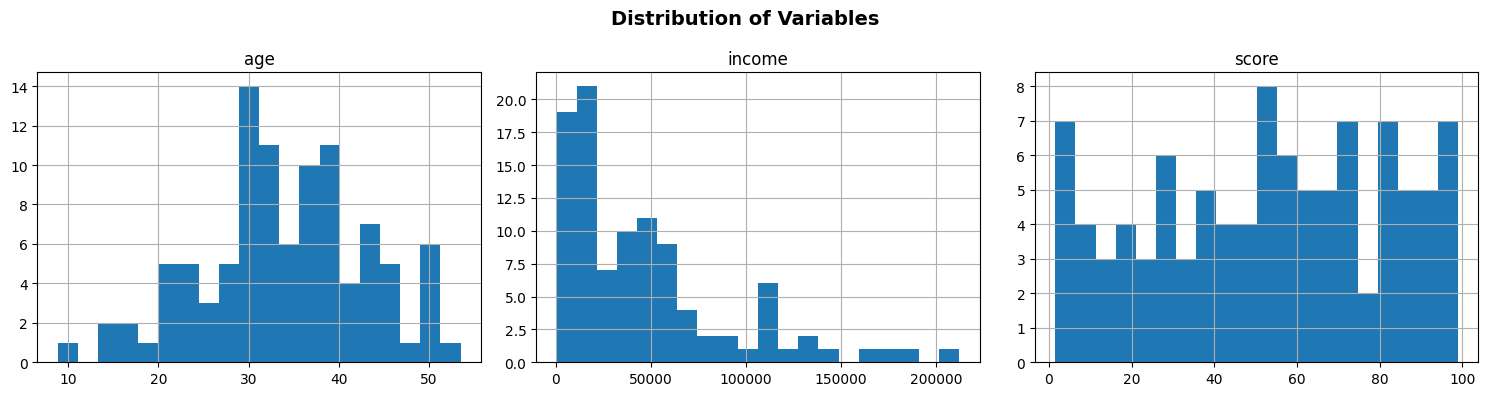

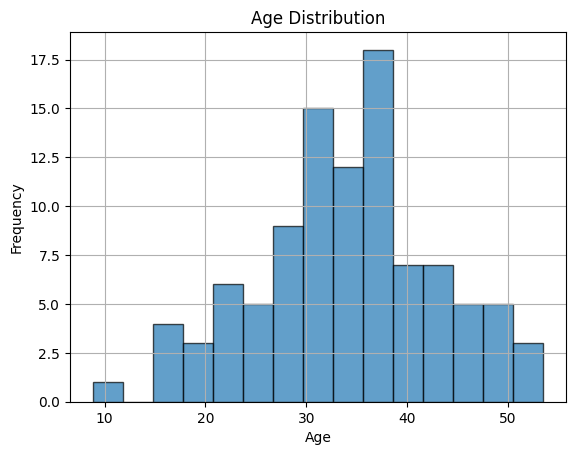

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create sample data
np.random.seed(42)
df = pd.DataFrame({
    'age': np.random.normal(35, 10, 100),
    'income': np.random.exponential(50000, 100),
    'score': np.random.uniform(0, 100, 100)
})

print("Data summary:")
print(df.describe())
print("\n" + "="*50 + "\n")

# Create histograms for all numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.hist(ax=axes.flatten(), bins=20)
plt.suptitle('Distribution of Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Individual histogram with more control
df['age'].hist(bins=15, edgecolor='black', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

---

## Quick Reference: When to Use Each Method

| Method | Use Case | Example |
|--------|----------|---------|
| `interpolate()` | Fill gaps in time-series data | Stock prices with missing days |
| `isin()` | Filter for multiple values | `df[df['status'].isin(['active', 'pending'])]` |
| `notna()` | Keep non-missing values | `df[df['column'].notna()]` |
| `nsmallest()` / `nlargest()` | Get top/bottom N items | `df.nlargest(10, 'sales')` |
| `eval()` | Complex multi-column operations | `df.eval('a + b * c')` |
| `ewm()` | Smooth time-series trends | Stock price moving averages |
| `idxmax()` / `idxmin()` | Find best/worst performer | `df.loc[df['sales'].idxmax()]` |
| `infer_objects()` | Fix data types after import | After reading CSV |
| `hist()` | Visualize distributions | Quick data exploration |

---

## Complete Working Example

In [14]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
df = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=30),
    'product': np.random.choice(['A', 'B', 'C'], 30),
    'sales': np.random.randint(100, 1000, 30),
    'status': np.random.choice(['active', 'inactive', 'pending'], 30)
})

# Add some missing values
df.loc[[5, 10, 15], 'sales'] = np.nan

print("Original DataFrame:")
print(df.head(10))
print("\n" + "="*50 + "\n")

# 1. Fill missing sales with interpolation
df['sales_filled'] = df['sales'].interpolate()
print("After interpolating missing sales:")
print(df[['date', 'sales', 'sales_filled']].head(10))
print("\n" + "="*50 + "\n")

# 2. Filter for active or pending items
active_pending = df[df['status'].isin(['active', 'pending'])]
print(f"Rows with active or pending status: {len(active_pending)}")
print("\n" + "="*50 + "\n")

# 3. Get top 5 products by sales
top_5 = df.nlargest(5, 'sales_filled')[['date', 'product', 'sales_filled']]
print("Top 5 sales:")
print(top_5)
print("\n" + "="*50 + "\n")

# 4. Calculate exponentially weighted mean of sales
df['ewm_sales'] = df['sales_filled'].ewm(span=5).mean()
print("Exponentially weighted sales (first 10):")
print(df[['date', 'sales_filled', 'ewm_sales']].head(10))
print("\n" + "="*50 + "\n")

# 5. Find the date with highest sales
best_date_idx = df['sales_filled'].idxmax()
best_date = df.loc[best_date_idx, 'date']
best_sales = df.loc[best_date_idx, 'sales_filled']
print(f"Best sales date: {best_date.date()} with ${best_sales:.0f}")

Original DataFrame:
        date product  sales    status
0 2024-01-01       C  781.0   pending
1 2024-01-02       A  575.0   pending
2 2024-01-03       C  799.0    active
3 2024-01-04       C  882.0   pending
4 2024-01-05       A  289.0   pending
5 2024-01-06       A    NaN  inactive
6 2024-01-07       C  662.0    active
7 2024-01-08       B  975.0  inactive
8 2024-01-09       C  666.0  inactive
9 2024-01-10       C  343.0  inactive


After interpolating missing sales:
        date  sales  sales_filled
0 2024-01-01  781.0         781.0
1 2024-01-02  575.0         575.0
2 2024-01-03  799.0         799.0
3 2024-01-04  882.0         882.0
4 2024-01-05  289.0         289.0
5 2024-01-06    NaN         475.5
6 2024-01-07  662.0         662.0
7 2024-01-08  975.0         975.0
8 2024-01-09  666.0         666.0
9 2024-01-10  343.0         343.0


Rows with active or pending status: 14


Top 5 sales:
         date product  sales_filled
28 2024-01-29       C         997.0
7  2024-01-08       B  

These advanced methods help you write more concise, powerful, and efficient data analysis code.

---

# Advanced Manipulation Techniques, Complex Transformations, and Non-Trivial Pandas Workflows

## Introduction

As you progress beyond basic data selection and filtering, pandas offers powerful techniques for reshaping, combining, and transforming data in sophisticated ways. This chapter explores workflows that solve real-world data challenges through method chaining, multi-level operations, and strategic use of pandas' most flexible functions.

---

## Method Chaining for Readable Workflows

Method chaining allows you to write expressive, readable code by connecting multiple operations in sequence. Rather than creating intermediate variables, you can pipe operations together.

In [15]:
import pandas as pd
import numpy as np

# Sample dataset
df = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=100),
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'value': np.random.randn(100).cumsum(),
    'quantity': np.random.randint(1, 100, 100)
})

# Without chaining (harder to read)
filtered = df[df['value'] > 0]
grouped = filtered.groupby('category')['value'].mean()
result = grouped.sort_values(ascending=False)

# With chaining (clearer intent)
result = (df
    .query('value > 0')
    .groupby('category')['value']
    .mean()
    .sort_values(ascending=False)
)

**Key benefits:**
- Reduces intermediate variable clutter
- Makes the transformation pipeline explicit
- Easier to debug by inserting print statements mid-chain

---

## Conditional Logic with `assign()` and `where()`

Creating new columns based on complex conditions is a common task. The `assign()` method enables clean, chainable column creation.

In [16]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=100),
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'value': np.random.randn(100).cumsum(),
    'quantity': np.random.randint(1, 100, 100)
})

# Create derived columns with assign()
df_enhanced = (df
    .assign(
        value_category=lambda x: pd.cut(x['value'],
                                        bins=3,
                                        labels=['Low', 'Medium', 'High']),
        is_high_volume=lambda x: x['quantity'] > x['quantity'].quantile(0.75),
        normalized_value=lambda x: (x['value'] - x['value'].mean()) / x['value'].std()
    )
)

# Use where() for conditional replacement
df['value_capped'] = df['value'].where(df['value'] < 10, 10)

# Combine multiple conditions
mask = (df['category'] == 'A') & (df['quantity'] > 50)
df.loc[mask, 'flag'] = 'priority'

The `assign()` method is particularly powerful because it returns a new DataFrame, preserving your original data and enabling chaining.

---

## Working with MultiIndex DataFrames

MultiIndex (hierarchical indexing) enables you to work with higher-dimensional data while maintaining a 2D DataFrame structure. This is particularly useful for time series data, categorical hierarchies, and grouped analyses.

### Creating a MultiIndex DataFrame

In [17]:
import pandas as pd
import numpy as np

# Create a MultiIndex from tuples
index = pd.MultiIndex.from_tuples([
    ('USA', 'New York', 2020),
    ('USA', 'New York', 2021),
    ('USA', 'California', 2020),
    ('USA', 'California', 2021),
    ('Canada', 'Toronto', 2020),
    ('Canada', 'Toronto', 2021)
], names=['Country', 'City', 'Year'])

data = np.random.randn(6, 3)
df = pd.DataFrame(data, index=index, columns=['Revenue', 'Expenses', 'Profit'])

print(df)

                          Revenue  Expenses    Profit
Country City       Year                              
USA     New York   2020  1.096330 -0.335411  0.635113
                   2021 -1.080201 -1.305698 -0.750762
        California 2020 -1.025500 -1.183040  0.449774
                   2021  1.778924 -0.666943 -1.691818
Canada  Toronto    2020  0.656797 -1.435901 -1.183266
                   2021  0.494996 -0.165310 -0.687175


### Cross-Sectional Selection with MultiIndex

In [18]:
# Select all data for a specific country
usa_data = df.loc['USA']

# Select specific city across all years
ny_data = df.loc[('USA', 'New York')]

# Select data for multiple countries
multi_country = df.loc[['USA', 'Canada']]

# Select a single row
recent_data = df.loc[('USA', 'New York', 2021)]

/var/folders/6k/wdwghqdd7ynf_52q9qqp3v9w0000gp/T/ipykernel_13187/1134391813.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  ny_data = df.loc[('USA', 'New York')]


### Reshaping with MultiIndex Levels

In [19]:
# Stack: convert column level to row index
stacked = df.stack()

# Unstack: convert index level to columns
unstacked = df.unstack(level='Year')

# Unstack multiple levels
unstacked_multi = df.unstack(level=['Year', 'City'])

### Multi-Index Operations in Practice

In [20]:
import pandas as pd
import numpy as np

# Create a multi-index DataFrame using from_product
index = pd.MultiIndex.from_product(
    [['Region1', 'Region2'], ['Q1', 'Q2', 'Q3', 'Q4'], ['Product_A', 'Product_B']],
    names=['region', 'quarter', 'product']
)
df_multi = pd.DataFrame({
    'sales': np.random.randint(1000, 5000, len(index)),
    'units': np.random.randint(10, 100, len(index))
}, index=index)

# Access specific levels
print(df_multi.loc['Region1'])           # All data for Region1
print(df_multi.loc[('Region1', 'Q1')])   # Specific region and quarter

# Aggregate across levels
quarterly_totals = df_multi.groupby(level='quarter')['sales'].sum()
product_performance = df_multi.groupby(level='product')['units'].mean()

# Stack and unstack for reshaping
stacked = df_multi.stack()
unstacked = df_multi.unstack(level='product')

                   sales  units
quarter product                
Q1      Product_A   3701     71
        Product_B   1971     31
Q2      Product_A   2906     67
        Product_B   3518     67
Q3      Product_A   2166     95
        Product_B   2115     58
Q4      Product_A   4425     61
        Product_B   1833     51
           sales  units
product                
Product_A   3701     71
Product_B   1971     31


---

## Advanced Grouping and Aggregation Patterns

Beyond simple `groupby()` operations, you can create sophisticated aggregation workflows that handle multiple transformations simultaneously.

### Named Aggregations for Clarity

In [21]:
import pandas as pd

sales_data = pd.DataFrame({
    'Region': ['North', 'North', 'South', 'South', 'East', 'East'],
    'Product': ['A', 'B', 'A', 'B', 'A', 'B'],
    'Sales': [100, 150, 200, 120, 180, 160],
    'Units': [10, 15, 20, 12, 18, 16]
})

# Named aggregations make the output more readable
result = sales_data.groupby('Region').agg(
    total_sales=('Sales', 'sum'),
    avg_sales=('Sales', 'mean'),
    total_units=('Units', 'sum'),
    sales_std=('Sales', 'std')
)

print(result)

        total_sales  avg_sales  total_units  sales_std
Region                                                
East            340      170.0           34  14.142136
North           250      125.0           25  35.355339
South           320      160.0           32  56.568542


### Conditional Aggregation

In [ ]:
# Apply different aggregations based on conditions
def custom_agg(group):
    return pd.Series({
        'high_sales': (group['Sales'] > 150).sum(),
        'total': group['Sales'].sum(),
        'ratio': (group['Sales'] > 150).sum() / len(group)
    })

conditional_result = sales_data.groupby('Region').apply(custom_agg, include_groups=False)

### Transforming Within Groups

In [23]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=100),
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'value': np.random.randn(100).cumsum(),
    'quantity': np.random.randint(1, 100, 100)
})

# Rank within groups
df['rank_in_category'] = df.groupby('category')['value'].rank(method='dense')

# Calculate percentile within groups
df['percentile'] = df.groupby('category')['value'].transform(
    lambda x: x.rank(pct=True)
)

# Apply multiple aggregations with named results
summary = df.groupby('category').agg({
    'value': ['mean', 'std', 'min', 'max'],
    'quantity': ['sum', 'count']
}).round(2)

# Custom aggregation function
def custom_stats(group):
    return pd.Series({
        'mean': group.mean(),
        'cv': group.std() / group.mean(),   # Coefficient of variation
        'range': group.max() - group.min()
    })

stats = df.groupby('category')['value'].apply(custom_stats)

# Transform to add results back to original shape
df['group_mean'] = df.groupby('category')['value'].transform('mean')
df['deviation'] = df['value'] - df['group_mean']

# Normalize sales within each region
sales_data['normalized_sales'] = sales_data.groupby('Region')['Sales'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Rank products within each region
sales_data['rank_in_region'] = sales_data.groupby('Region')['Sales'].transform('rank')

print(sales_data)

  Region Product  Sales  Units  normalized_sales  rank_in_region
0  North       A    100     10         -0.707107             1.0
1  North       B    150     15          0.707107             2.0
2  South       A    200     20          0.707107             2.0
3  South       B    120     12         -0.707107             1.0
4   East       A    180     18          0.707107             2.0
5   East       B    160     16         -0.707107             1.0


---

## Combining Multiple DataFrames with Complex Logic

Real-world scenarios often require merging data from multiple sources with non-trivial join conditions.

### Standard Merges

In [24]:
import pandas as pd

customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'region': ['North', 'South', 'North', 'East', 'West']
})

orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106],
    'customer_id': [1, 2, 2, 3, 5, 5],
    'amount': [100, 250, 150, 300, 75, 200]
})

# Standard inner join
merged = pd.merge(customers, orders, on='customer_id', how='inner')

# Left join to preserve all customers
all_customers = pd.merge(customers, orders, on='customer_id', how='left')

# Merge with validation to ensure data integrity
validated = pd.merge(
    customers,
    orders,
    on='customer_id',
    how='left',
    validate='1:m'   # One customer can have many orders
)

print(validated)

   customer_id     name region  order_id  amount
0            1    Alice  North     101.0   100.0
1            2      Bob  South     102.0   250.0
2            2      Bob  South     103.0   150.0
3            3  Charlie  North     104.0   300.0
4            4    Diana   East       NaN     NaN
5            5      Eve   West     105.0    75.0
6            5      Eve   West     106.0   200.0


### Merge on Multiple Keys

In [25]:
import pandas as pd

transactions = pd.DataFrame({
    'customer_id': [1, 1, 2, 2],
    'date': pd.date_range('2023-01-01', periods=4),
    'amount': [50, 75, 100, 125]
})

customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'region': ['North', 'South', 'North', 'East', 'West']
})

# Merge on multiple columns
detailed = pd.merge(
    customers,
    transactions,
    on='customer_id',
    how='left'
)

# Concatenate datasets vertically
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})
combined = pd.concat([df1, df2], ignore_index=True)

### Asof Merge for Time Series Data

In [26]:
import pandas as pd

trades = pd.DataFrame({
    'time': pd.to_datetime(['2023-01-01 09:00', '2023-01-01 09:30',
                            '2023-01-01 10:00', '2023-01-01 10:30']),
    'price': [100, 102, 101, 103]
})

quotes = pd.DataFrame({
    'time': pd.to_datetime(['2023-01-01 09:15', '2023-01-01 09:45',
                            '2023-01-01 10:15']),
    'bid': [99, 100, 100],
    'ask': [101, 103, 102]
})

# Find the nearest preceding quote for each trade
result = pd.merge_asof(trades, quotes, on='time', direction='backward')
print(result)

                 time  price    bid    ask
0 2023-01-01 09:00:00    100    NaN    NaN
1 2023-01-01 09:30:00    102   99.0  101.0
2 2023-01-01 10:00:00    101  100.0  103.0
3 2023-01-01 10:30:00    103  100.0  102.0


---

## Pivoting and Reshaping Data

Transforming data between long and wide formats is essential for analysis and visualization.

### Pivot with Multiple Aggregations

In [27]:
import pandas as pd

sales_detail = pd.DataFrame({
    'Date': pd.date_range('2023-01-01', periods=6),
    'Region': ['North', 'South', 'North', 'South', 'North', 'South'],
    'Product': ['A', 'A', 'B', 'B', 'A', 'B'],
    'Sales': [100, 150, 200, 120, 180, 160],
    'Units': [10, 15, 20, 12, 18, 16]
})

# Pivot with multiple value columns
pivot_result = sales_detail.pivot_table(
    index='Date',
    columns=['Region', 'Product'],
    values=['Sales', 'Units'],
    aggfunc='sum'
)

print(pivot_result)

            Sales                      Units                  
Region      North         South        North       South      
Product         A      B      A      B     A     B     A     B
Date                                                          
2023-01-01  100.0    NaN    NaN    NaN  10.0   NaN   NaN   NaN
2023-01-02    NaN    NaN  150.0    NaN   NaN   NaN  15.0   NaN
2023-01-03    NaN  200.0    NaN    NaN   NaN  20.0   NaN   NaN
2023-01-04    NaN    NaN    NaN  120.0   NaN   NaN   NaN  12.0
2023-01-05  180.0    NaN    NaN    NaN  18.0   NaN   NaN   NaN
2023-01-06    NaN    NaN    NaN  160.0   NaN   NaN   NaN  16.0


### Melt for Unpivoting

In [28]:
import pandas as pd

wide_data = pd.DataFrame({
    'Product': ['A', 'B', 'C'],
    'Q1': [100, 150, 200],
    'Q2': [120, 160, 210],
    'Q3': [130, 170, 220]
})

# Convert from wide to long format
long_data = pd.melt(
    wide_data,
    id_vars=['Product'],
    var_name='Quarter',
    value_name='Revenue'
)

print(long_data)

  Product Quarter  Revenue
0       A      Q1      100
1       B      Q1      150
2       C      Q1      200
3       A      Q2      120
4       B      Q2      160
5       C      Q2      210
6       A      Q3      130
7       B      Q3      170
8       C      Q3      220


### Unpivoting Multiple Column Groups

In [29]:
import pandas as pd

df_wide = pd.DataFrame({
    'id': [1, 2, 3],
    'Q1_sales': [100, 200, 150],
    'Q2_sales': [120, 210, 160],
    'Q1_costs': [50, 100, 75],
    'Q2_costs': [55, 105, 80]
})

df_long = df_wide.melt(
    id_vars='id',
    var_name='metric',
    value_name='amount'
)

# Separate combined column names into quarter and type
df_long[['quarter', 'type']] = df_long['metric'].str.split('_', expand=True)
print(df_long)

    id    metric  amount quarter   type
0    1  Q1_sales     100      Q1  sales
1    2  Q1_sales     200      Q1  sales
2    3  Q1_sales     150      Q1  sales
3    1  Q2_sales     120      Q2  sales
4    2  Q2_sales     210      Q2  sales
5    3  Q2_sales     160      Q2  sales
6    1  Q1_costs      50      Q1  costs
7    2  Q1_costs     100      Q1  costs
8    3  Q1_costs      75      Q1  costs
9    1  Q2_costs      55      Q2  costs
10   2  Q2_costs     105      Q2  costs
11   3  Q2_costs      80      Q2  costs


---

## Window Functions and Rolling Calculations

Perform calculations over sliding windows of data, essential for time series analysis.

### Rolling Statistics with Custom Functions

In [30]:
import pandas as pd
import numpy as np

stock_data = pd.DataFrame({
    'Date': pd.date_range('2023-01-01', periods=20),
    'Price': np.random.randn(20).cumsum() + 100
})

# Calculate multiple rolling statistics
stock_data['MA_5'] = stock_data['Price'].rolling(window=5).mean()
stock_data['Volatility'] = stock_data['Price'].rolling(window=5).std()
stock_data['Min_5'] = stock_data['Price'].rolling(window=5).min()
stock_data['Max_5'] = stock_data['Price'].rolling(window=5).max()

# Custom rolling function
stock_data['Range_5'] = stock_data['Price'].rolling(window=5).apply(
    lambda x: x.max() - x.min()
)

print(stock_data.head(10))

        Date       Price        MA_5  Volatility      Min_5       Max_5  \
0 2023-01-01  101.096330         NaN         NaN        NaN         NaN   
1 2023-01-02  100.760919         NaN         NaN        NaN         NaN   
2 2023-01-03  101.396031         NaN         NaN        NaN         NaN   
3 2023-01-04  100.315830         NaN         NaN        NaN         NaN   
4 2023-01-05   99.010133  100.515849    0.932594  99.010133  101.396031   
5 2023-01-06   98.259371   99.948457    1.286856  98.259371  101.396031   
6 2023-01-07   97.233871   99.243047    1.646577  97.233871  101.396031   
7 2023-01-08   96.050832   98.174007    1.634436  96.050832  100.315830   
8 2023-01-09   96.500606   97.410962    1.223439  96.050832   99.010133   
9 2023-01-10   98.279530   97.264842    1.009643  96.050832   98.279530   

    Range_5  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4  2.385898  
5  3.136660  
6  4.162160  
7  4.264999  
8  2.959301  
9  2.228698  


### Expanding Windows

In [31]:
# Expanding window: grows from 1 to n observations
stock_data['Cumulative_Mean'] = stock_data['Price'].expanding().mean()
stock_data['Cumulative_Max'] = stock_data['Price'].expanding().max()

# Expanding with min_periods
stock_data['Expanding_Std'] = stock_data['Price'].expanding(min_periods=3).std()

### Rolling Operations by Group

In [32]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=100),
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'value': np.random.randn(100).cumsum(),
    'quantity': np.random.randint(1, 100, 100)
})

# Rolling averages
df['rolling_mean'] = df['value'].rolling(window=7, center=True).mean()
df['rolling_std'] = df['value'].rolling(window=7).std()

# Expanding calculations
df['cumulative_sum'] = df['value'].expanding().sum()
df['expanding_mean'] = df['value'].expanding().mean()

# Exponential weighted moving average
df['ewma'] = df['value'].ewm(span=10).mean()

# Rolling operations by group
df['group_rolling_mean'] = df.groupby('category')['value'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

---

## Handling Missing Data in Complex Scenarios

Beyond simple `fillna()`, handle missing data strategically based on context.

### Forward and Backward Fill with Limits

In [33]:
import pandas as pd
import numpy as np

time_series = pd.DataFrame({
    'Date': pd.date_range('2023-01-01', periods=10),
    'Value': [1, np.nan, np.nan, 4, np.nan, np.nan, np.nan, 8, np.nan, 10]
})

# Forward fill with limit
time_series['FFill_Limited'] = time_series['Value'].ffill(limit=1)

# Backward fill
time_series['BFill'] = time_series['Value'].bfill()

# Interpolation
time_series['Interpolated'] = time_series['Value'].interpolate(method='linear')

print(time_series)

        Date  Value  FFill_Limited  BFill  Interpolated
0 2023-01-01    1.0            1.0    1.0           1.0
1 2023-01-02    NaN            1.0    4.0           2.0
2 2023-01-03    NaN            NaN    4.0           3.0
3 2023-01-04    4.0            4.0    4.0           4.0
4 2023-01-05    NaN            4.0    8.0           5.0
5 2023-01-06    NaN            NaN    8.0           6.0
6 2023-01-07    NaN            NaN    8.0           7.0
7 2023-01-08    8.0            8.0    8.0           8.0
8 2023-01-09    NaN            8.0   10.0           9.0
9 2023-01-10   10.0           10.0   10.0          10.0


### Interpolation Methods

In [34]:
import pandas as pd
import numpy as np

# Different interpolation strategies
data_with_gaps = pd.DataFrame({
    'x': [0, 1, 2, 3, 4, 5],
    'y': [0, np.nan, np.nan, np.nan, 4, 5]
})

data_with_gaps['linear'] = data_with_gaps['y'].interpolate(method='linear')
data_with_gaps['polynomial'] = data_with_gaps['y'].interpolate(method='polynomial', order=2)
data_with_gaps['nearest'] = data_with_gaps['y'].interpolate(method='nearest')

print(data_with_gaps)

   x    y  linear  polynomial  nearest
0  0  0.0     0.0         0.0      0.0
1  1  NaN     1.0         1.0      0.0
2  2  NaN     2.0         2.0      0.0
3  3  NaN     3.0         3.0      4.0
4  4  4.0     4.0         4.0      4.0
5  5  5.0     5.0         5.0      5.0


### Filling with Group Statistics

In [35]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'value': np.random.randn(100).cumsum()
})

# Introduce some missing values
df.loc[df.sample(10).index, 'value'] = np.nan

# Identify missing patterns
missing_report = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Forward fill within groups
df['value_ffill'] = df.groupby('category')['value'].ffill()

# Fill with group mean
df['value_group_mean'] = df.groupby('category')['value'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill with group median
df['value_filled'] = df['value'].fillna(
    df.groupby('category')['value'].transform('median')
)

---

## String Operations and Text Processing

Leverage pandas' string methods for sophisticated text manipulation.

### Vectorized String Operations

In [36]:
import pandas as pd

text_data = pd.DataFrame({
    'ID': [1, 2, 3, 4],
    'Text': ['Hello World', 'PANDAS DATA', 'python Programming', 'SQL Query']
})

# String methods are vectorized
text_data['lowercase'] = text_data['Text'].str.lower()
text_data['word_count'] = text_data['Text'].str.split().str.len()
text_data['contains_data'] = text_data['Text'].str.contains('Data', case=False)
text_data['first_word'] = text_data['Text'].str.split().str[0]

print(text_data)

   ID                Text           lowercase  word_count  contains_data  \
0   1         Hello World         hello world           2          False   
1   2         PANDAS DATA         pandas data           2           True   
2   3  python Programming  python programming           2          False   
3   4           SQL Query           sql query           2          False   

  first_word  
0      Hello  
1     PANDAS  
2     python  
3        SQL  


### Pattern Extraction with Regex

In [37]:
import pandas as pd

email_data = pd.DataFrame({
    'Email': ['john.doe@company.com', 'jane_smith@email.co.uk', 'bob@test.org']
})

# Extract domain
email_data['domain'] = email_data['Email'].str.extract(r'@(.+)$')

# Extract username
email_data['username'] = email_data['Email'].str.extract(r'^([^@]+)@')

# Check for dot in address
email_data['has_dot'] = email_data['Email'].str.contains(r'\.')

print(email_data)

                    Email       domain    username  has_dot
0    john.doe@company.com  company.com    john.doe     True
1  jane_smith@email.co.uk  email.co.uk  jane_smith     True
2            bob@test.org     test.org         bob     True


### String Cleaning and Encoding

In [38]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'location': ['North-01', 'South-02', 'East-03', 'West-04'] * 25,
    'text': ['  Hello World  ', 'PANDAS  data', 'python  prog', 'SQL query  '] * 25
})

# String replacement and stripping
df['cleaned'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Split a combined column
df[['region', 'code']] = df['location'].str.split('-', expand=True)

# Categorical encoding from strings
df['category_code'] = pd.Categorical(df['category']).codes

---

## Categorical Data for Memory Efficiency

Use categorical data types to reduce memory usage and improve performance on repetitive values.

In [39]:
import pandas as pd
import numpy as np

large_data = pd.DataFrame({
    'ID': range(1000000),
    'Category': np.random.choice(['A', 'B', 'C', 'D'], 1000000),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 1000000)
})

# Check memory before conversion
print("Memory before conversion:")
print(large_data.memory_usage(deep=True))

# Convert to categorical
large_data['Category'] = large_data['Category'].astype('category')
large_data['Region'] = large_data['Region'].astype('category')

# Check memory after conversion
print("\nMemory after conversion:")
print(large_data.memory_usage(deep=True))

# Categorical operations
category_counts = large_data['Category'].value_counts()
print(category_counts)

Memory before conversion:
Index            128
ID           8000000
Category    58000000
Region      61499903
dtype: int64

Memory after conversion:
Index           128
ID          8000000
Category    1000404
Region      1000418
dtype: int64
Category
A    250231
D    250044
C    249974
B    249751
Name: count, dtype: int64


---

## Performance Optimization Techniques

For large datasets, strategic choices significantly impact speed.

### Using `eval()` and `query()` for Large Computations

In [40]:
import pandas as pd
import numpy as np

df_large = pd.DataFrame({
    'A': np.random.randn(100000),
    'B': np.random.randn(100000),
    'C': np.random.randn(100000)
})

# Using eval for complex expressions (avoids intermediate arrays)
result = df_large.eval('D = A + B * C', inplace=False)

# Query with eval for readable filtering
threshold = 0.0
target_cat = 'A'
filtered = df_large.query('A > 0 and B < 0.5')

### Vectorize Instead of Looping

In [41]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'value': np.random.randn(100000),
    'quantity': np.random.randint(1, 100, 100000),
    'offset': np.random.randn(100000)
})

# Use np.where instead of apply for conditional logic
df['result'] = np.where(df['value'] > 0, df['value'] * 2, 0)

# Use eval for complex multi-column expressions
df['combined'] = df.eval('value * quantity + offset')

# Use itertuples for row iteration when looping is unavoidable
# (faster than iterrows)
for row in df.head(5).itertuples():
    print(row.value, row.quantity)

0.4967141530112327 36
-0.13826430117118466 18
0.6476885381006925 5
1.5230298564080254 46
-0.23415337472333597 86


### Chunking Large Files

In [ ]:
import pandas as pd

# Generate a small sample file for demonstration
pd.DataFrame({'value': range(10000)}).to_csv('large_file.csv', index=False)

# Process large CSV files in chunks to avoid memory issues
chunk_size = 10000
chunks = []

for chunk in pd.read_csv('large_file.csv', chunksize=chunk_size):
    processed = chunk[chunk['value'] > 100]
    chunks.append(processed)

result = pd.concat(chunks, ignore_index=True)

### Chaining Operations for Readable Pipelines

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
sales_data = pd.DataFrame({
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 200),
    'Sales': np.random.randint(50, 500, 200),
    'Units': np.random.randint(1, 50, 200)
})

result = (sales_data
    .query('Sales > 100')
    .groupby('Region')
    .agg(
        total_sales=('Sales', 'sum'),
        avg_units=('Units', 'mean')
    )
    .sort_values('total_sales', ascending=False)
    .reset_index()
    .assign(sales_category=lambda x: pd.cut(x['total_sales'], bins=3))
)

print(result)

---

## Conclusion

Mastering these advanced techniques transforms pandas from a data access tool into a comprehensive data transformation engine. The key is understanding when to use each approach: method chaining for clarity, groupby for aggregation, reshaping for analysis, window functions for time-series work, and categorical types for memory efficiency. Practice combining these techniques to build robust, efficient data pipelines.

---

# Exercises

Test your understanding of this chapter's concepts.

### Exercise 1: Method Chaining and Conditional Assignment

Practice building readable workflows using method chaining combined with assign() and where(). Create a sales DataFrame and use chaining to clean, transform, and categorize the data in a single pipeline.

In [ ]:
import pandas as pd
import numpy as np

# Sample sales data
data = {
    'product': ['Widget A', 'Widget B', 'Gadget X', 'Gadget Y', 'Widget A', 'Gadget X'],
    'revenue': [1500, 850, 3200, 4100, 920, 2750],
    'units_sold': [30, 17, 64, 82, 18, 55],
    'region': ['north', 'south', 'north', 'east', 'east', 'south']
}
df = pd.DataFrame(data)

# TODO 1: Use method chaining to:
#   - Add a column 'revenue_per_unit' = revenue / units_sold (use assign())
#   - Add a column 'category' that is 'High' if revenue >= 2000, else 'Low' (use assign() + where())
#   - Sort the result by revenue descending
#   - Reset the index
# Store the result in 'result'
result = None

# TODO 2: Print the result DataFrame


### Exercise 2: Rolling Window Calculations

Use window functions to compute rolling statistics on time-series data. Given a DataFrame of daily temperatures, calculate rolling averages and identify days where the temperature exceeded the rolling mean.

In [ ]:
import pandas as pd
import numpy as np

# Daily temperature data
data = {
    'date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'temperature': [22, 19, 25, 30, 28, 24, 21, 27, 33, 29]
}
df = pd.DataFrame(data).set_index('date')

# TODO 1: Add a column 'rolling_mean_3' containing the 3-day rolling mean
#         of the 'temperature' column (use a window of 3)

# TODO 2: Add a column 'rolling_std_3' containing the 3-day rolling
#         standard deviation of the 'temperature' column

# TODO 3: Add a boolean column 'above_rolling_mean' that is True when
#         'temperature' is greater than 'rolling_mean_3'

# TODO 4: Print the final DataFrame


### Exercise 3: Advanced GroupBy Aggregation and Pivoting

Apply advanced groupby aggregation using multiple functions at once, then reshape the result using pivot_table. Work with an employee dataset to summarize salary statistics by department and job level.

In [ ]:
import pandas as pd
import numpy as np

# Employee dataset
data = {
    'department': ['Engineering', 'Engineering', 'Marketing', 'Marketing',
                   'Engineering', 'Marketing', 'HR', 'HR', 'HR', 'Engineering'],
    'level': ['Senior', 'Junior', 'Senior', 'Junior',
              'Senior', 'Senior', 'Junior', 'Senior', 'Junior', 'Junior'],
    'salary': [95000, 62000, 88000, 54000, 102000, 91000, 48000, 75000, 45000, 67000]
}
df = pd.DataFrame(data)

# TODO 1: Group by 'department' and 'level', then aggregate 'salary' to get
#         mean, min, max, and count. Store the result in 'grouped'.
#         Hint: use .agg() with a dictionary or list
grouped = None

# TODO 2: Flatten the MultiIndex columns if needed and reset the index

# TODO 3: Create a pivot table from the ORIGINAL df showing the mean salary
#         for each 'department' (rows) and 'level' (columns).
#         Store the result in 'pivot'
pivot = None

# TODO 4: Print both 'grouped' and 'pivot'


### Exercise 4: String Operations, Missing Data, and Categorical Conversion

Practice text processing with string accessor methods, handle missing values in a realistic scenario, and convert appropriate columns to categorical dtype for memory efficiency. Work with a customer records DataFrame that contains messy text and NaN values.

In [ ]:
import pandas as pd
import numpy as np

# Messy customer records
data = {
    'customer_id': [101, 102, 103, 104, 105, 106],
    'full_name': ['  alice johnson ', 'BOB SMITH', 'Carol White  ', None, 'dave brown', '  EVE DAVIS'],
    'email': ['alice@example.com', 'bob@EXAMPLE.COM', None, 'dan@example.com', None, 'eve@example.com'],
    'membership': ['gold', 'silver', 'gold', 'bronze', 'silver', 'bronze'],
    'purchases': [15, np.nan, 8, 22, np.nan, 5]
}
df = pd.DataFrame(data)

# TODO 1: Clean the 'full_name' column:
#         - Strip leading/trailing whitespace
#         - Convert to title case
#         - Fill any NaN values with 'Unknown'

# TODO 2: Clean the 'email' column:
#         - Convert all emails to lowercase
#         - Leave NaN values as NaN for now (do NOT fill them yet)

# TODO 3: Fill missing values in 'purchases' with the median of that column

# TODO 4: Convert the 'membership' column to categorical dtype
#         and print its memory usage before and after conversion
#         Hint: use df.memory_usage(deep=True)

# TODO 5: Print the cleaned DataFrame


---

# Solutions

*Scroll down only after you've attempted the exercises above.*

<br><br><br><br><br><br><br><br><br><br>

### Solution 1: Method Chaining and Conditional Assignment

In [ ]:
import pandas as pd
import numpy as np

# Sample sales data
data = {
    'product': ['Widget A', 'Widget B', 'Gadget X', 'Gadget Y', 'Widget A', 'Gadget X'],
    'revenue': [1500, 850, 3200, 4100, 920, 2750],
    'units_sold': [30, 17, 64, 82, 18, 55],
    'region': ['north', 'south', 'north', 'east', 'east', 'south']
}
df = pd.DataFrame(data)

# Method chaining with assign() and where()
result = (
    df
    .assign(revenue_per_unit=lambda x: x['revenue'] / x['units_sold'])
    .assign(category=lambda x: pd.Series('High').where(x['revenue'] >= 2000, 'Low').reindex(x.index, fill_value='Low'))
    .assign(category=lambda x: np.where(x['revenue'] >= 2000, 'High', 'Low'))
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)

print(result)


### Solution 2: Rolling Window Calculations

In [ ]:
import pandas as pd
import numpy as np

# Daily temperature data
data = {
    'date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'temperature': [22, 19, 25, 30, 28, 24, 21, 27, 33, 29]
}
df = pd.DataFrame(data).set_index('date')

# TODO 1: 3-day rolling mean
df['rolling_mean_3'] = df['temperature'].rolling(window=3).mean()

# TODO 2: 3-day rolling standard deviation
df['rolling_std_3'] = df['temperature'].rolling(window=3).std()

# TODO 3: Boolean column — temperature above rolling mean
df['above_rolling_mean'] = df['temperature'] > df['rolling_mean_3']

# TODO 4: Print the final DataFrame
print(df)


### Solution 3: Advanced GroupBy Aggregation and Pivoting

In [ ]:
import pandas as pd
import numpy as np

# Employee dataset
data = {
    'department': ['Engineering', 'Engineering', 'Marketing', 'Marketing',
                   'Engineering', 'Marketing', 'HR', 'HR', 'HR', 'Engineering'],
    'level': ['Senior', 'Junior', 'Senior', 'Junior',
              'Senior', 'Senior', 'Junior', 'Senior', 'Junior', 'Junior'],
    'salary': [95000, 62000, 88000, 54000, 102000, 91000, 48000, 75000, 45000, 67000]
}
df = pd.DataFrame(data)

# TODO 1: GroupBy with multiple aggregations
grouped = df.groupby(['department', 'level'])['salary'].agg(
    mean_salary='mean',
    min_salary='min',
    max_salary='max',
    count='count'
)

# TODO 2: Reset the index to flatten the MultiIndex
grouped = grouped.reset_index()

# TODO 3: Pivot table — mean salary by department and level
pivot = pd.pivot_table(
    df,
    values='salary',
    index='department',
    columns='level',
    aggfunc='mean'
)

# TODO 4: Print results
print('Grouped Aggregation:')
print(grouped)
print('\nPivot Table:')
print(pivot)


### Solution 4: String Operations, Missing Data, and Categorical Conversion

In [ ]:
import pandas as pd
import numpy as np

# Messy customer records
data = {
    'customer_id': [101, 102, 103, 104, 105, 106],
    'full_name': ['  alice johnson ', 'BOB SMITH', 'Carol White  ', None, 'dave brown', '  EVE DAVIS'],
    'email': ['alice@example.com', 'bob@EXAMPLE.COM', None, 'dan@example.com', None, 'eve@example.com'],
    'membership': ['gold', 'silver', 'gold', 'bronze', 'silver', 'bronze'],
    'purchases': [15, np.nan, 8, 22, np.nan, 5]
}
df = pd.DataFrame(data)

# TODO 1: Clean 'full_name'
df['full_name'] = (
    df['full_name']
    .str.strip()
    .str.title()
    .fillna('Unknown')
)

# TODO 2: Clean 'email' — lowercase only, keep NaN
df['email'] = df['email'].str.lower()

# TODO 3: Fill missing 'purchases' with median
df['purchases'] = df['purchases'].fillna(df['purchases'].median())

# TODO 4: Convert 'membership' to categorical and compare memory usage
print('Memory usage BEFORE categorical conversion:')
print(df.memory_usage(deep=True)['membership'], 'bytes')

df['membership'] = df['membership'].astype('category')

print('Memory usage AFTER categorical conversion:')
print(df.memory_usage(deep=True)['membership'], 'bytes')

# TODO 5: Print the cleaned DataFrame
print('\nCleaned DataFrame:')
print(df)
